# Profile Results Analyze

Analyze `chunk_setting_profile_results.csv` to determine the best variant (FA vs FD-x) for each `(n_beams, prompt_len)` combination.

Rule: if the best FD-x is at least **2 ms** faster than FA, FD-x wins. Otherwise the difference is treated as noise and FA is reported.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba
from matplotlib.patches import Rectangle

# Match config.model_path used by chunk_setting_profile.py.
MODEL_PATH = 'Qwen/QWen2.5-1.5B-Instruct'

# Notebook lives in scripts/; project root is one level up.
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / MODEL_PATH
FIGURES_DIR = PROJECT_ROOT / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_DIR / 'chunk_setting_profile_results.csv'
TIE_THRESHOLD_MS = 2.0

## 1. Load data and pick the best variant per (n_beams, prompt_len)

In [30]:
df = pd.read_csv(CSV_PATH, comment='#')
df.columns = [c.strip() for c in df.columns]
df = df[['n_beams', 'prompt_len', 'variant', 'time_ms']].copy()
df['n_beams'] = df['n_beams'].astype(int)
df['prompt_len'] = df['prompt_len'].astype(int)
df['time_ms'] = df['time_ms'].astype(float)
df.head()

,n_beams,prompt_len,variant,time_ms
0,1,192,FA,98.880153
1,1,192,FD-4,121.728036
2,1,192,FD-6,122.815454
3,1,192,FD-8,126.563795
4,1,256,FA,100.994642


In [31]:
fa = (
    df[df['variant'] == 'FA']
    .rename(columns={'time_ms': 'fa_time_ms'})[['n_beams', 'prompt_len', 'fa_time_ms']]
)

fd = df[df['variant'].str.startswith('FD-')].copy()
fd_best_idx = fd.groupby(['n_beams', 'prompt_len'])['time_ms'].idxmin()
fd_best = fd.loc[fd_best_idx].rename(
    columns={'variant': 'best_fd_variant', 'time_ms': 'best_fd_time_ms'}
)[['n_beams', 'prompt_len', 'best_fd_variant', 'best_fd_time_ms']]

merged = fa.merge(fd_best, on=['n_beams', 'prompt_len'], how='outer')
merged.head()

,n_beams,prompt_len,fa_time_ms,best_fd_variant,best_fd_time_ms
0,1,192,98.880153,FD-4,121.728036
1,1,256,100.994642,FD-4,119.805019
2,1,320,102.979938,FD-16,122.655651
3,1,384,105.011112,FD-4,120.396107
4,1,448,117.402583,FD-4,131.855075


## 2. Decide winner: FA unless best FD-x beats FA by >= 2 ms

In [32]:
def pick_winner(row):
    fa_t = row['fa_time_ms']
    fd_t = row['best_fd_time_ms']
    fd_v = row['best_fd_variant']
    if pd.isna(fd_t):
        return pd.Series({'winner': 'FA', 'winner_time_ms': fa_t, 'fd_minus_fa_ms': np.nan})
    if pd.isna(fa_t):
        return pd.Series({'winner': fd_v, 'winner_time_ms': fd_t, 'fd_minus_fa_ms': np.nan})
    diff = fa_t - fd_t  # positive means FD is faster
    if diff >= TIE_THRESHOLD_MS:
        return pd.Series({'winner': fd_v, 'winner_time_ms': fd_t, 'fd_minus_fa_ms': -diff})
    return pd.Series({'winner': 'FA', 'winner_time_ms': fa_t, 'fd_minus_fa_ms': -diff})

merged[['winner', 'winner_time_ms', 'fd_minus_fa_ms']] = merged.apply(pick_winner, axis=1)
merged.head(20)

,n_beams,prompt_len,fa_time_ms,best_fd_variant,best_fd_time_ms,winner,winner_time_ms,fd_minus_fa_ms
0,1,192,98.880153,FD-4,121.728036,FA,98.880153,22.847883
1,1,256,100.994642,FD-4,119.805019,FA,100.994642,18.810377
2,1,320,102.979938,FD-16,122.655651,FA,102.979938,19.675713
3,1,384,105.011112,FD-4,120.396107,FA,105.011112,15.384995
4,1,448,117.402583,FD-4,131.855075,FA,117.402583,14.452492
5,1,512,135.600511,FD-4,149.960928,FA,135.600511,14.360417
6,1,576,154.815662,FD-4,167.611109,FA,154.815662,12.795447
7,1,640,180.233037,FD-32,190.621460,FA,180.233037,10.388423
8,1,704,199.775357,FD-32,207.636359,FA,199.775357,7.861002
9,1,768,220.597469,FD-4,226.359289,FA,220.597469,5.761820


## 3. Pivot to a (n_beams x prompt_len) table and save

In [33]:
winner_table = merged.pivot(index='n_beams', columns='prompt_len', values='winner').sort_index()
winner_table = winner_table.reindex(sorted(winner_table.columns), axis=1)
winner_table.to_csv(DATA_DIR / 'profile_results_best_method.csv')
winner_table

prompt_len,192,256,320,384,448,512,576,640,704,768,...,1792,2048,2304,2560,2816,3072,3328,3584,3840,4096
n_beams,,,,,,,,,,,,,,,,,,,,,
1,FA,FA,FA,FA,FA,FA,FA,FA,FA,FA,...,FD-32,FD-6,FD-16,FD-32,FD-4,FD-8,FD-32,FD-6,FD-4,FD-16
2,FA,FA,FA,FA,FA,FA,FA,FA,FD-8,FD-6,...,FD-32,FD-32,FD-8,FD-4,FD-8,FD-32,FD-32,FD-6,FD-8,FD-6
4,FA,FA,FA,FA,FD-4,FD-8,FD-4,FD-8,FD-4,FD-4,...,FD-8,FD-8,FD-16,FD-8,FD-8,FD-8,FD-16,FD-8,FD-16,FD-16
8,FA,FA,FA,FA,FD-8,FD-6,FD-8,FD-16,FD-8,FD-6,...,FD-8,FD-6,FD-8,FD-8,FD-8,FD-16,FD-16,FD-16,FD-16,FD-16
16,FA,FA,FA,FA,FA,FA,FA,FD-8,FD-4,FD-8,...,FD-16,FD-8,FD-16,FD-16,FD-16,FD-16,FD-16,FD-16,FD-16,FD-32
24,FA,FA,FA,FA,FA,FA,FA,FD-16,FD-16,FD-8,...,FD-6,FD-16,FD-16,FD-8,FD-32,FD-32,FD-32,FD-32,FD-32,FD-32
32,FA,FA,FA,FA,FA,FA,FA,FD-16,FD-8,FD-4,...,FD-16,FD-6,FD-32,FD-32,FD-32,FD-16,FD-16,FD-32,FD-32,FD-16
40,FA,FA,FA,FA,FA,FA,FD-16,FD-16,FD-6,FD-16,...,FD-32,FD-8,FD-16,FD-16,FD-32,FD-16,FD-16,FD-8,FD-16,FD-16
48,FA,FA,FA,FA,FA,FD-16,FD-6,FD-6,FD-6,FD-16,...,FD-32,FD-16,FD-32,FD-8,FD-16,FD-16,FD-16,FD-64,FD-32,FD-32


In [34]:
# Companion table with the actual time of the chosen winner (handy for debugging).
time_table = merged.pivot(index='n_beams', columns='prompt_len', values='winner_time_ms').sort_index()
time_table = time_table.reindex(sorted(time_table.columns), axis=1)
time_table.round(2).head()

prompt_len,192,256,320,384,448,512,576,640,704,768,...,1792,2048,2304,2560,2816,3072,3328,3584,3840,4096
n_beams,,,,,,,,,,,,,,,,,,,,,
1,98.88,100.99,102.98,105.01,117.40,135.60,154.82,180.23,199.78,220.60,...,531.73,609.87,687.73,764.53,838.39,905.56,991.61,1062.03,1144.55,1207.11
2,103.99,107.33,108.56,110.94,124.31,144.00,164.44,191.94,209.77,228.59,...,532.45,605.78,688.93,769.31,838.83,915.43,992.59,1073.07,1150.91,1242.32
4,115.51,117.77,120.34,122.41,133.71,151.55,169.93,193.78,212.22,230.01,...,537.15,623.38,706.45,782.63,856.69,940.57,1028.28,1124.57,1195.05,1283.65
8,118.20,120.30,122.69,125.10,135.68,153.47,172.05,197.37,214.69,233.06,...,547.67,633.97,720.63,803.62,882.20,972.21,1058.10,1146.52,1232.49,1333.14
16,113.88,116.55,118.61,121.28,135.62,156.25,177.65,201.67,221.22,239.97,...,559.86,642.19,724.65,811.90,884.53,975.96,1059.46,1144.40,1234.68,1377.19


## 4. Block-diagram visualization of a coarse subset

FA cells are yellow. FD-x cells are green, with darker green for larger `x`.

In [35]:
# Coarse selections from what's available in the CSV.
all_beams = sorted(winner_table.index.tolist())
all_prompts = sorted(winner_table.columns.tolist())

coarse_beams = [b for b in [1, 2, 4, 8, 16, 32, 64, 96, 128] if b in all_beams]
# Build coarse prompts from the wish list, then drop any that the actual
# sweep did not measure (e.g. the start_len for this model > 256, so
# the smaller column doesn't exist in winner_table).
_wish_prompts = [256+64*2, 256+64*3, 256+64*4, 256+64*5, 256+64*6, 256+64*7, 256+64*8, 256+64*9, 256+64*10, 960, 1024]
coarse_prompts = [p for p in _wish_prompts if p in all_prompts]

sub = winner_table.loc[coarse_beams, coarse_prompts]
sub

prompt_len,384,448,512,576,640,704,768,832,896,960,1024
n_beams,,,,,,,,,,,
1,FA,FA,FA,FA,FA,FA,FA,FA,FA,FD-16,FD-4
2,FA,FA,FA,FA,FA,FD-8,FD-6,FD-32,FD-8,FD-6,FD-16
4,FA,FD-4,FD-8,FD-4,FD-8,FD-4,FD-4,FD-8,FD-8,FD-6,FD-8
8,FA,FD-8,FD-6,FD-8,FD-16,FD-8,FD-6,FD-4,FD-8,FD-4,FD-4
16,FA,FA,FA,FA,FD-8,FD-4,FD-8,FD-8,FD-32,FD-16,FD-16
32,FA,FA,FA,FA,FD-16,FD-8,FD-4,FD-4,FD-6,FD-4,FD-8
64,FA,FD-8,FD-6,FD-16,FD-6,FD-16,FD-16,FD-16,FD-16,FD-16,FD-6
96,FA,FA,FD-8,FD-8,FD-6,FD-8,FD-8,FD-32,FD-32,FD-32,FD-16
128,FA,FA,FA,FA,FA,FD-8,FD-32,FD-32,FD-32,FD-32,FA


In [36]:
FA_COLOR = '#ffb4bd'  # yellow

fd_x_values = sorted({
    int(v.split('-')[1])
    for v in winner_table.values.ravel()
    if isinstance(v, str) and v.startswith('FD-')
})

def fd_color(x: int) -> tuple:
    if not fd_x_values:
        return to_rgba('#92d050')
    x_min, x_max = min(fd_x_values), max(fd_x_values)
    if x_max == x_min:
        t = 0.5
    else:
        t = (x - x_min) / (x_max - x_min)
    # Interpolate between a light green and a deep green.
    light = np.array(to_rgba('#d1ebb4'))
    dark = np.array(to_rgba('#6ca72d'))
    return tuple(light + (dark - light) * t)

def cell_color(label: str):
    if not isinstance(label, str) or label == 'FA':
        return FA_COLOR
    if label.startswith('FD-'):
        return fd_color(int(label.split('-')[1]))
    return '#cccccc'

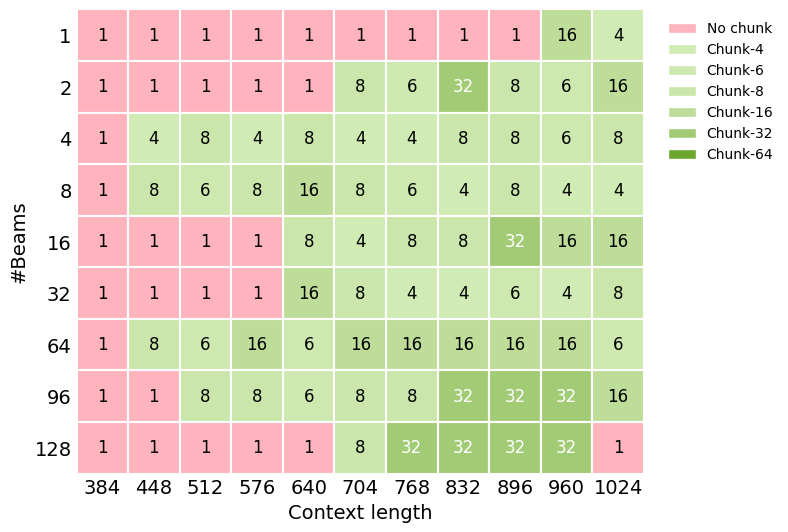

In [47]:
# fig, ax = plt.subplots(figsize=(7, 4))
fig, ax = plt.subplots(figsize=(8, 7))

n_rows, n_cols = len(coarse_beams), len(coarse_prompts)
for i, beam in enumerate(coarse_beams):
    for j, plen in enumerate(coarse_prompts):
        label = sub.loc[beam, plen]
        color = cell_color(label)
        ax.add_patch(Rectangle((j, n_rows - 1 - i), 1, 1, facecolor=color, edgecolor='white', linewidth=1.5))
        cell_text = ('1' if label == 'FA' else label.split('-')[1]) if isinstance(label, str) else '-'
        ax.text(j + 0.5, n_rows - 1 - i + 0.5, cell_text,
                ha='center', va='center', fontsize=12,
                color='black' if (label == 'FA' or (isinstance(label, str) and label.startswith('FD-') and int(label.split('-')[1]) <= 16)) else 'white')

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(coarse_prompts)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(list(reversed(coarse_beams)))
ax.set_xlabel('Context length', fontsize=14)
ax.set_ylabel('#Beams', fontsize=14)
ax.set_aspect('equal')
ax.tick_params(length=0, labelsize=14)
for s in ax.spines.values():
    s.set_visible(False)

# Legend.
legend_handles = [Rectangle((0, 0), 1, 1, facecolor=FA_COLOR, edgecolor='white', label='No chunk')]
for x in fd_x_values:
    legend_handles.append(Rectangle((0, 0), 1, 1, facecolor=fd_color(x), edgecolor='white', label=f'Chunk-{x}'))
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'chunk_profile_results_visualize_Llama.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'chunk_profile_results_visualize_Qwen.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Parallelism heatmap (grayscale)

For the same coarse `(n_beams, prompt_len)` subset, compute

    parallelism = n_beams * n_chunks * n_heads,  n_heads = 2

where `n_chunks = 1` for FA cells and `n_chunks = ceil(prompt_len / (16 * x))` for FD-x cells.

Cells are colored on a grayscale ramp — darker = more parallelism — with the parallelism value labeled in each block.

In [10]:
import math

N_HEADS = 2
BLOCK_SIZE_TOK = 16  # matches BLOCK_SIZE in the profiler

def n_chunks_for(label: str, prompt_len: int) -> int:
    if not isinstance(label, str):
        return 0
    if label == 'FA':
        return 1
    if label.startswith('FD-'):
        x = int(label.split('-')[1])
        return math.ceil(prompt_len / (BLOCK_SIZE_TOK * x))
    return 0

parallelism = pd.DataFrame(index=coarse_beams, columns=coarse_prompts, dtype=float)
for b in coarse_beams:
    for p in coarse_prompts:
        label = sub.loc[b, p]
        nc = n_chunks_for(label, p)
        parallelism.loc[b, p] = b * nc * N_HEADS if nc else np.nan
parallelism.astype('Int64')

,256,320,384,448,512,576,640,704,768,832,896,960,1024
1,2,2,2,2,2,2,2,16,6,8,8,30,16
2,4,4,4,28,32,36,28,32,48,52,56,32,32
4,8,8,8,56,48,48,56,64,64,72,80,64,88
8,16,16,16,80,96,96,112,96,128,112,112,128,128
16,32,32,32,128,128,160,96,96,96,128,128,128,128
32,64,64,64,64,64,64,64,64,64,448,128,128,256
64,128,128,128,128,128,128,128,128,128,128,128,128,128


/tmp/ipykernel_1308781/121404050.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Greys')


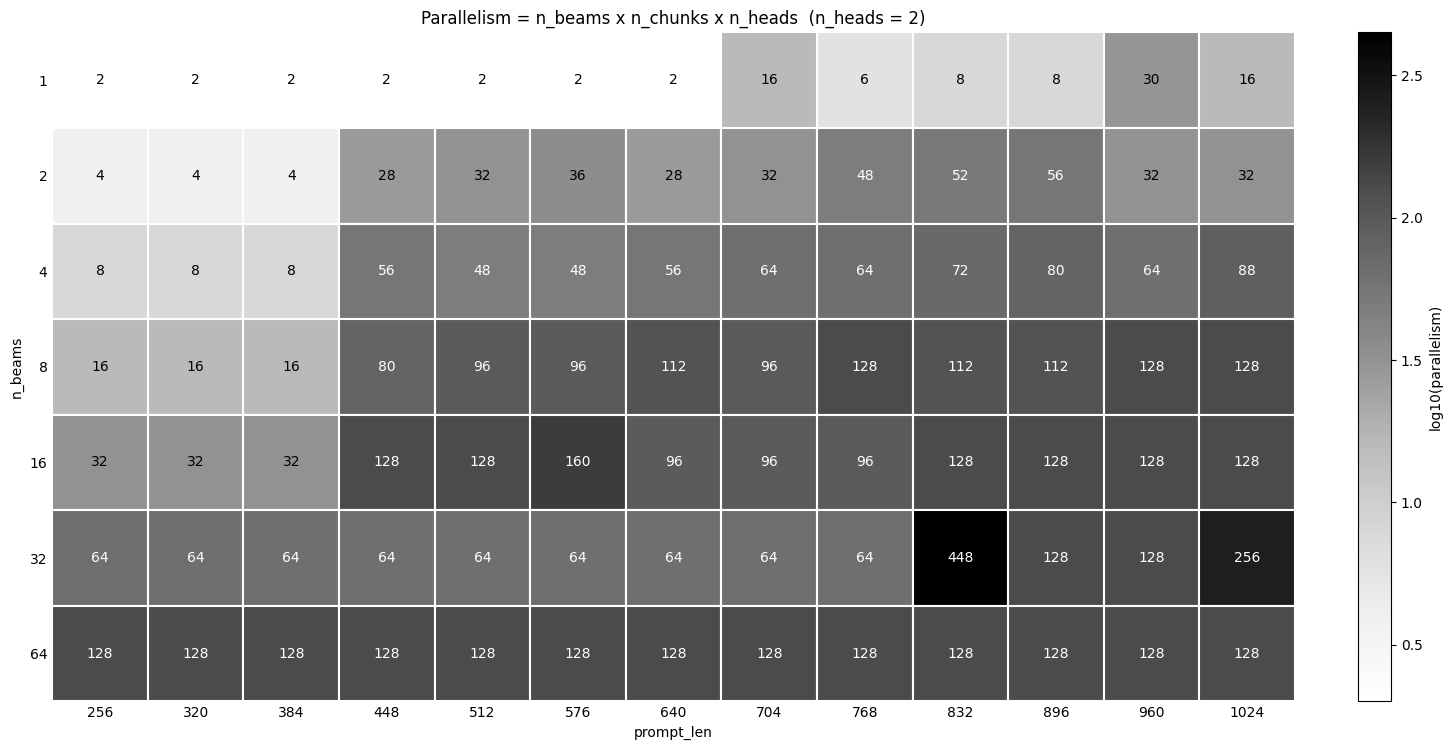

In [11]:
from matplotlib import cm
from matplotlib.colors import Normalize

vals = parallelism.to_numpy(dtype=float)
finite = vals[np.isfinite(vals)]
vmin = float(finite.min()) if finite.size else 0.0
vmax = float(finite.max()) if finite.size else 1.0

# Use log scale: parallelism varies over orders of magnitude.
norm = Normalize(vmin=np.log10(max(vmin, 1.0)), vmax=np.log10(max(vmax, 1.0)))
cmap = cm.get_cmap('Greys')

fig, ax = plt.subplots(figsize=(1.1 * len(coarse_prompts) + 2, 0.8 * len(coarse_beams) + 2))
n_rows, n_cols = len(coarse_beams), len(coarse_prompts)
for i, beam in enumerate(coarse_beams):
    for j, plen in enumerate(coarse_prompts):
        v = parallelism.loc[beam, plen]
        if pd.isna(v):
            color = '#ffffff'; text = '-'; tcolor = 'black'
        else:
            t = norm(np.log10(max(v, 1.0)))
            color = cmap(t)
            text = f'{int(v)}'
            tcolor = 'white' if t > 0.55 else 'black'
        ax.add_patch(Rectangle((j, n_rows - 1 - i), 1, 1, facecolor=color, edgecolor='white', linewidth=1.5))
        ax.text(j + 0.5, n_rows - 1 - i + 0.5, text, ha='center', va='center', fontsize=10, color=tcolor)

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(coarse_prompts)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(list(reversed(coarse_beams)))
ax.set_xlabel('prompt_len')
ax.set_ylabel('n_beams')
ax.set_title('Parallelism = n_beams x n_chunks x n_heads  (n_heads = 2)')
ax.set_aspect('equal')
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

# Colorbar in original (linear) parallelism units.
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('log10(parallelism)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'profile_results_parallelism.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Export a runtime LUT for best-of-n dispatch

Encode the full `(n_beams, prompt_len) → best variant` table as a compact lookup the runtime can consume:

- `csp_grid[i, j]` is the value to assign to `cpd.PROFILE_CHUNK_SIZE_PAGE`:
  - `0` &nbsp;&rarr; FA path  (interpreted as `None` at runtime)
  - `N` &nbsp;&rarr; FD path with `CHUNK_Size_Page = N`
- `n_beams_axis[i]` and `prompt_len_axis[j]` are the sorted grid axes.
- `lookup(live_n_beams, live_kv_len)` does a **floor-nearest** lookup on both axes — i.e. picks the largest measured grid point that does not exceed the live value. Floor (rather than round-to-nearest) is the conservative choice: at the boundary we'd rather still recommend the kernel that's been validated on a slightly *smaller* workload.

Saved files:
- `profile_results_lut.json` &mdash; portable, human-readable.
- `profile_results_lut.npz` &mdash; numpy-friendly for fast in-process load.

In [12]:
import json


def label_to_csp(label):
    """0 -> FA (runtime: PROFILE_CHUNK_SIZE_PAGE = None); N -> FD-N."""
    if not isinstance(label, str) or label == 'FA':
        return 0
    if label.startswith('FD-'):
        return int(label.split('-')[1])
    return 0  # default to FA for missing/unknown

n_beams_axis = sorted(winner_table.index.tolist())
prompt_len_axis = sorted(winner_table.columns.tolist())

csp_grid = np.zeros((len(n_beams_axis), len(prompt_len_axis)), dtype=np.int16)
for i, b in enumerate(n_beams_axis):
    for j, p in enumerate(prompt_len_axis):
        csp_grid[i, j] = label_to_csp(winner_table.loc[b, p])

# Forward-fill missing cells (NaN winners at the upper-right of the grid where
# n_beams * prompt_len exceeded the memory budget) along the prompt_len axis,
# so the LUT still returns a sensible recommendation in that regime.
for i in range(len(n_beams_axis)):
    last_good = 0
    for j in range(len(prompt_len_axis)):
        if pd.isna(winner_table.iloc[i, j]):
            csp_grid[i, j] = last_good
        else:
            last_good = csp_grid[i, j]

print('csp_grid shape:', csp_grid.shape)
print('unique CSP values:', sorted(np.unique(csp_grid).tolist()))
csp_grid

csp_grid shape: (11, 26)
unique CSP values: [0, 4, 6, 8, 16, 32, 64]


array([[ 0,  0,  0,  0,  0,  0,  0,  0,  6, 16, 16, 16,  4,  8,  6,  8,
         6,  8,  6,  8,  8,  8,  6,  8,  8, 16],
       [ 0,  0,  0,  0,  4,  4,  4,  6,  6,  4,  4,  4,  8,  8,  4,  8,
         6,  8,  8,  8,  8,  8, 16, 16, 16, 16],
       [ 0,  0,  0,  0,  4,  6,  6,  6,  6,  6,  6,  6,  8,  6,  8,  8,
         8,  8,  8, 16, 16, 16, 16, 16, 16, 16],
       [ 0,  0,  0,  0,  6,  6,  6,  6,  8,  6,  8,  8,  8,  8, 16, 16,
        16, 16, 16, 32, 32, 32, 32, 32, 32, 32],
       [ 0,  0,  0,  0,  8,  8,  8, 16, 16, 16, 16, 16, 16, 16,  6,  8,
        32, 32, 32,  8, 16, 16, 16, 16, 64, 64],
       [ 8,  0,  0,  0,  0,  0,  0, 16, 16,  6,  6, 32, 32,  8, 32,  8,
         8, 16, 16, 16, 64, 16, 16, 16, 16, 32],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  8, 32, 32, 16,  8, 16,
        64, 16, 32, 16, 16, 16, 32, 16, 64, 32],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 32, 32, 16,  6, 16, 16,
        64, 16, 16, 16, 32, 16, 32, 64, 32, 16],
       [ 0,  0,  0,  0,  0,  0, 

In [13]:
def _floor_index(axis, value):
    """Largest i such that axis[i] <= value; clamp to 0 if value < axis[0]."""
    arr = np.asarray(axis)
    i = int(np.searchsorted(arr, value, side='right') - 1)
    return max(i, 0)

def lookup(live_n_beams: int, live_kv_len: int) -> int:
    """Return the CSP value (0 = FA, N = FD-N) recommended by the LUT.

    Floor-nearest on both axes: rounds the live workload DOWN to the nearest
    measured grid point. Caller assigns to cpd.PROFILE_CHUNK_SIZE_PAGE,
    interpreting 0 as None.
    """
    i = _floor_index(n_beams_axis, live_n_beams)
    j = _floor_index(prompt_len_axis, live_kv_len)
    return int(csp_grid[i, j])

# Smoke-test a few realistic best-of-n operating points.
demo = [
    (1, 256), (1, 1024), (1, 4096),
    (8, 512), (8, 2048),
    (16, 1500), (32, 3000),
    (96, 800), (96, 4096),
    (5, 700),    # off-grid n_beams (between 4 and 8) and prompt_len (between 640/704)
    (200, 5000), # past the right edge: clamps to last column
]
for nb, kv in demo:
    csp = lookup(nb, kv)
    label = 'FA' if csp == 0 else f'FD-{csp}'
    print(f'live n_beams={nb:>4}, kv_len={kv:>5}  ->  CSP={csp:>3}  ({label})')

live n_beams=   1, kv_len=  256  ->  CSP=  0  (FA)
live n_beams=   1, kv_len= 1024  ->  CSP=  8  (FD-8)
live n_beams=   1, kv_len= 4096  ->  CSP= 16  (FD-16)
live n_beams=   8, kv_len=  512  ->  CSP=  6  (FD-6)
live n_beams=   8, kv_len= 2048  ->  CSP= 16  (FD-16)
live n_beams=  16, kv_len= 1500  ->  CSP=  6  (FD-6)
live n_beams=  32, kv_len= 3000  ->  CSP= 16  (FD-16)
live n_beams=  96, kv_len=  800  ->  CSP=  0  (FA)
live n_beams=  96, kv_len= 4096  ->  CSP=  0  (FA)
live n_beams=   5, kv_len=  700  ->  CSP=  6  (FD-6)
live n_beams= 200, kv_len= 5000  ->  CSP=  0  (FA)


In [14]:
# Save the LUT in two formats.
lut_payload = {
    'description': 'Best CHUNK_Size_Page per (n_beams, prompt_len) for vLLM chunked-prefill paged decode. 0 = FA (PROFILE_CHUNK_SIZE_PAGE = None); N = FD-N.',
    'tie_threshold_ms': TIE_THRESHOLD_MS,
    'block_size': 16,
    'n_heads_assumed': 2,
    'n_beams_axis': [int(b) for b in n_beams_axis],
    'prompt_len_axis': [int(p) for p in prompt_len_axis],
    'csp_grid': csp_grid.astype(int).tolist(),
}

json_path = DATA_DIR / 'profile_results_lut.json'
json_path.write_text(json.dumps(lut_payload, indent=2))
print(f'Wrote {json_path}  ({json_path.stat().st_size} bytes)')

npz_path = DATA_DIR / 'profile_results_lut.npz'
np.savez(
    npz_path,
    n_beams_axis=np.asarray(n_beams_axis, dtype=np.int32),
    prompt_len_axis=np.asarray(prompt_len_axis, dtype=np.int32),
    csp_grid=csp_grid.astype(np.int16),
    tie_threshold_ms=np.float32(TIE_THRESHOLD_MS),
    block_size=np.int32(16),
    n_heads_assumed=np.int32(2),
)
print(f'Wrote {npz_path}  ({npz_path.stat().st_size} bytes)')

Wrote ./data/meta-llama/Llama-3.2-1B-Instruct/profile_results_lut.json  (3439 bytes)
Wrote ./data/meta-llama/Llama-3.2-1B-Instruct/profile_results_lut.npz  (2298 bytes)


### Runtime usage sketch

To consume the LUT in vLLM's best-of-n loop:

```python
import json, numpy as np
from vllm.attention.ops import chunked_prefill_paged_decode as cpd

_lut = json.load(open(f'data/{MODEL_PATH}/profile_results_lut.json'))
_NB = np.asarray(_lut['n_beams_axis'])
_PL = np.asarray(_lut['prompt_len_axis'])
_GRID = np.asarray(_lut['csp_grid'], dtype=np.int16)

def pick_csp(live_n_beams: int, live_kv_len: int):
    i = max(int(np.searchsorted(_NB, live_n_beams, side='right') - 1), 0)
    j = max(int(np.searchsorted(_PL, live_kv_len, side='right') - 1), 0)
    csp = int(_GRID[i, j])
    return None if csp == 0 else csp

# Hook before each decode step:
cpd.PROFILE_CHUNK_SIZE_PAGE = pick_csp(live_n_beams, max_kv_len_in_step)
```

For batches that mix multiple best-of-n groups, pass the dominant group's `(n_beams, kv_len)` (e.g. the one maximizing `n_beams * kv_len`) — a single global flip can't be optimal for all groups simultaneously.